# FCNN — Grilla disco → Sensores

Prototipo en **PyTorch** de una red fully-connected que aprende el mapeo

$$ \text{B}_{\text{grilla}}(x, y\,|\,z_0) \;\longrightarrow\; \text{B}_{\text{sensores}}(z_0) $$

- **Entrada**: valores del campo magnético en una grilla 2D (plano XY) dentro del resonador, a un `z` fijo.
  - Rango XY: de -150 a 150 mm con paso de 10 mm → 31×31.
- **Salida**: campo magnético en los 36 sensores cuyo `z` coincide con el plano de la grilla.

Los datasets son generados por `utils/disco.jl` (función `simular_disco_batch`), que consume los NPZ de imanes perturbados producidos por `utils/perturb.jl` (función `perturb_batch`). El resultado es **un único NPZ consolidado** en `data/simulaciones/` con todas las muestras apiladas (shape `(N, Nx, Ny, 3)` para la grilla y `(N, K, 3)` para los sensores).

## 0. Instalación (ejecutar una sola vez)

Descomenta la celda siguiente si PyTorch no está instalado.

In [69]:
#%pip install torch --index-url https://download.pytorch.org/whl/cu121

In [70]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}  |  device: {DEVICE}")

torch 2.5.1+cu121  |  device: cuda


## 1. Configuración

Todos los parámetros del experimento en un solo bloque. Modificar aquí para cambiar comportamiento.

In [ ]:
# --- Ruta al NPZ consolidado producido por simular_disco_batch (Julia) ---
REPO_ROOT = Path("..").resolve()
NPZ_PATH  = REPO_ROOT / "data" / "simulaciones" / "disco_z0_both_n5000.npz"

# --- Parámetros de la grilla XY (deben coincidir con los usados en simular_disco_batch) ---
# El NPZ no persiste estos valores; se usan para reconstruir grid_xy localmente.
XY_STEP = 10.0      # mm
XY_MIN  = -150.0    # mm
XY_MAX  =  150.0    # mm

# --- Features de entrada/salida ---
# 'xyz' = usa Bx,By,Bz (recomendado). 'z' = solo Bz. 'norm' = |B|.
INPUT_COMPONENTS  = "xyz"
OUTPUT_COMPONENTS = "xyz"

# --- Split ---
VAL_FRAC  = 0.15
TEST_FRAC = 0.15

# --- Modelo ---
# Techo actual con 5000 samples: val R² ≈ 0.28 con [128, 64] + dropout 0.2.
# CNN probada y descartada a priori
HIDDEN_LAYERS = [128, 64]
ACTIVATION    = "relu"          # 'relu' | 'gelu' | 'tanh'
DROPOUT       = 0.2

# --- Entrenamiento ---
BATCH_SIZE    = 128
N_EPOCHS      = 300
LR            = 1e-3
WEIGHT_DECAY  = 1e-5
PATIENCE      = 40              # early stopping sobre val loss

# --- Salida ---
OUT_DIR = REPO_ROOT / "data" / "modelos"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_TAG = f"fcnn_{NPZ_PATH.stem}_{INPUT_COMPONENTS}2{OUTPUT_COMPONENTS}"
print(f"NPZ_PATH = {NPZ_PATH}")
print(f"RUN_TAG  = {RUN_TAG}")

NPZ_PATH = C:\Users\Poney\Desktop\Ipre\PMDKernel\data\simulaciones\disco_z0_both_n5000.npz
RUN_TAG  = fcnn_disco_z0_both_n5000_xyz2xyz


## 2. Carga del dataset consolidado

Lee el NPZ producido por `simular_disco_batch`. Contiene `N` muestras apiladas y el mínimo de metadatos no reconstruibles sin releer el CSV de sensores:

| Clave        | Shape            | Unidad | Descripción                                     |
|--------------|------------------|--------|-------------------------------------------------|
| `B_grid`     | `(N, Nx, Ny, 3)` | mT     | campo en la grilla XY (canales Bx, By, Bz)      |
| `B_sens`     | `(N, K, 3)`      | mT     | campo en los K sensores del plano               |
| `sens_xyz`   | `(K, 3)`         | mm     | posiciones de los sensores (evita releer CSV)   |
| `z_disco`    | escalar          | mm     | plano z del disco                               |

La grilla `grid_xy` se **reconstruye localmente** con `XY_MIN/MAX/STEP` (deben coincidir con los parámetros usados en `simular_disco_batch`). El loader valida shapes y atrapa mismatches.

Se forman los tensores `X` (N, n_in) y `y` (N, n_out) concatenando las componentes pedidas.

In [72]:
def _pick_components(B, mode):
    """B shape (..., 3). Devuelve (..., C) según el modo."""
    if mode == "xyz":
        return B
    if mode == "z":
        return B[..., 2:3]
    if mode == "norm":
        return np.linalg.norm(B, axis=-1, keepdims=True)
    raise ValueError(f"mode desconocido: {mode!r}")


def build_grid_xy(xy_min, xy_max, xy_step):
    """Reconstruye la malla XY (Nx, Ny, 2) con el mismo layout que usa Julia."""
    gx = np.arange(xy_min, xy_max + xy_step / 2, xy_step, dtype=np.float32)
    gxx, gyy = np.meshgrid(gx, gx, indexing="ij")
    return np.stack([gxx, gyy], axis=-1)


def load_disco_dataset(npz_path, input_mode="xyz", output_mode="xyz"):
    d = np.load(npz_path)
    B_grid   = d["B_grid"]
    B_sens   = d["B_sens"]
    sens_xyz = d["sens_xyz"]
    z_disco  = float(d["z_disco"])

    # --- Validación de shapes ---
    assert B_grid.ndim == 4 and B_grid.shape[-1] == 3, f"B_grid shape inesperado: {B_grid.shape}"
    assert B_sens.ndim == 3 and B_sens.shape[-1] == 3, f"B_sens shape inesperado: {B_sens.shape}"
    assert B_grid.shape[0] == B_sens.shape[0], \
        f"N inconsistente: grid={B_grid.shape[0]} sens={B_sens.shape[0]}"
    assert sens_xyz.shape == (B_sens.shape[1], 3), \
        f"sens_xyz shape inesperado: {sens_xyz.shape} (esperado ({B_sens.shape[1]}, 3))"
    assert B_grid.dtype == np.float32 and B_sens.dtype == np.float32, \
        f"dtypes inesperados: B_grid={B_grid.dtype}, B_sens={B_sens.dtype}"

    N, Nx, Ny, _ = B_grid.shape
    K = B_sens.shape[1]

    X = _pick_components(B_grid, input_mode).reshape(N, -1).astype(np.float32)
    y = _pick_components(B_sens, output_mode).reshape(N, -1).astype(np.float32)

    grid_xy = build_grid_xy(XY_MIN, XY_MAX, XY_STEP)
    assert grid_xy.shape == (Nx, Ny, 2), \
        f"Mismatch XY_*/NPZ: grid_xy={grid_xy.shape} vs B_grid=({Nx},{Ny}). Revisar XY_MIN/XY_MAX/XY_STEP."

    meta = {
        "grid_xy":    grid_xy,
        "sens_xyz":   sens_xyz,
        "z_disco":    z_disco,
        "grid_shape": (Nx, Ny),
        "K":          K,
    }
    return X, y, meta


X_all, y_all, meta = load_disco_dataset(
    NPZ_PATH, input_mode=INPUT_COMPONENTS, output_mode=OUTPUT_COMPONENTS,
)

N          = X_all.shape[0]
n_in       = X_all.shape[1]
n_out      = y_all.shape[1]
n_sensores = meta["K"]
Nx, Ny     = meta["grid_shape"]

gx = meta["grid_xy"][..., 0]
gy = meta["grid_xy"][..., 1]

print(f"Muestras               : {N}")
print(f"Shape de la grilla     : {Nx} x {Ny}  (n_in = {n_in})")
print(f"Sensores en plano z={meta['z_disco']:+.1f} mm : {n_sensores}  (n_out = {n_out})")
print(f"Rango grilla XY        : x in [{gx.min():.0f}, {gx.max():.0f}] mm, "
      f"y in [{gy.min():.0f}, {gy.max():.0f}] mm")

if N < 20:
    print("\nPocos datasets — el entrenamiento solo sirve para validar el pipeline.\n"
          "Aumenta N con perturb_batch + simular_disco_batch antes de interpretar métricas.")

Muestras               : 5000
Shape de la grilla     : 31 x 31  (n_in = 2883)
Sensores en plano z=+0.0 mm : 36  (n_out = 108)
Rango grilla XY        : x in [-150, 150] mm, y in [-150, 150] mm


## 3. Exploración — primeras 5 muestras

Grilla de 5 × 3: cada fila es una muestra, cada columna es una componente (Bx, By, Bz) del campo magnético en el plano del disco. Los sensores aparecen como cruces negras. El eje X está invertido para respetar la convención física del resonador (+x a la izquierda). La escala de color es simétrica y compartida entre muestras dentro de cada componente.

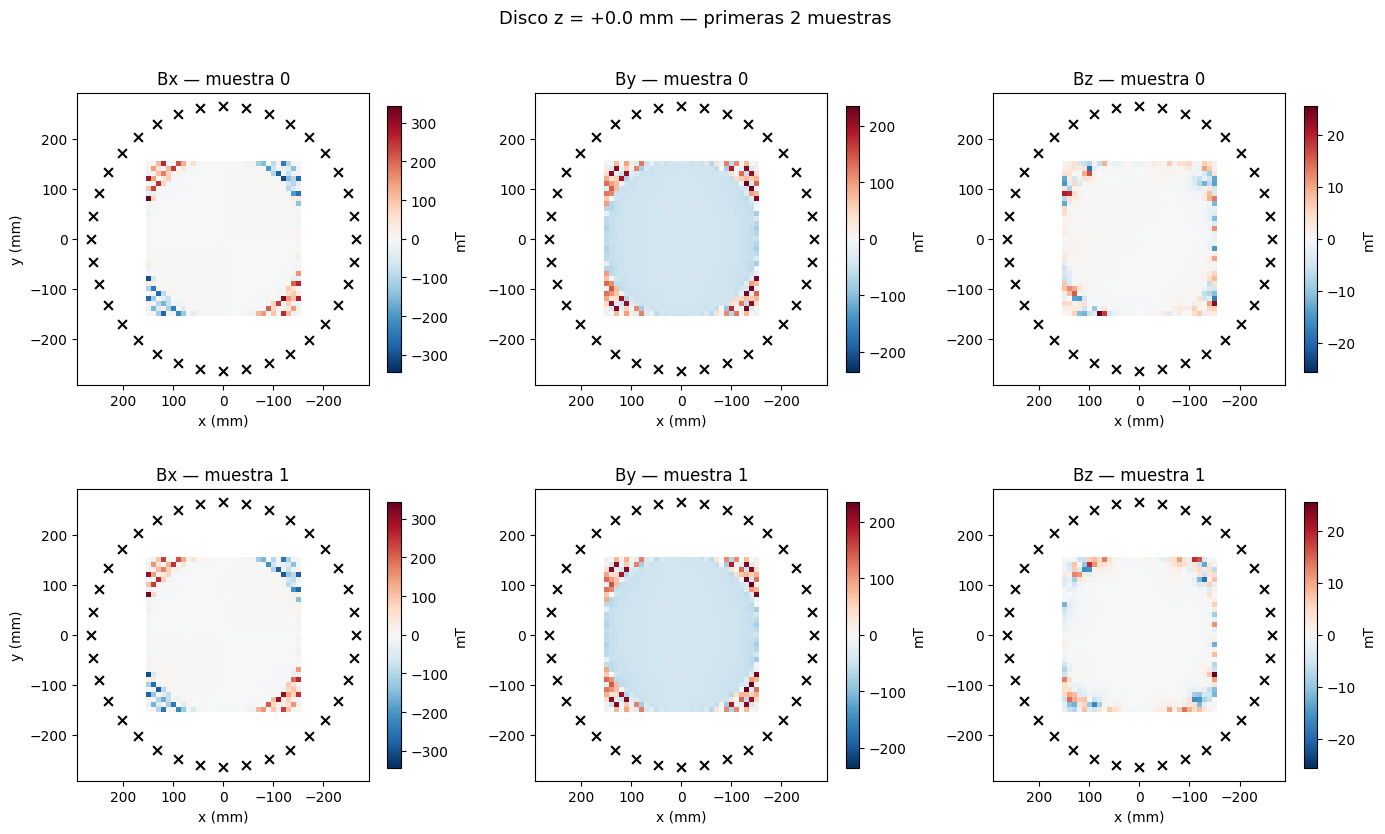

In [82]:
# Primeras 2 muestras — plots de Bx, By, Bz en la grilla + sensores
d = np.load(NPZ_PATH)
N_SHOW = min(2, d["B_grid"].shape[0])
COMPONENTS = ["Bx", "By", "Bz"]

fig, axes = plt.subplots(N_SHOW, 3, figsize=(14, 4.2 * N_SHOW), squeeze=False)

# escala simétrica por componente, compartida entre muestras para comparación visual
vmaxs = [float(np.max(np.abs(d["B_grid"][:N_SHOW, :, :, c]))) for c in range(3)]

for i in range(N_SHOW):
    for c, (name, vmax) in enumerate(zip(COMPONENTS, vmaxs)):
        ax = axes[i, c]
        im = ax.pcolormesh(gx, gy, d["B_grid"][i, :, :, c],
                           shading="auto", cmap="RdBu_r",
                           vmin=-vmax, vmax=vmax)
        ax.scatter(meta["sens_xyz"][:, 0], meta["sens_xyz"][:, 1],
                   c="k", s=40, marker="x", zorder=3)
        ax.set_aspect("equal")
        ax.invert_xaxis()   # convención física del resonador: +x a la izquierda
        ax.set_title(f"{name} — muestra {i}")
        ax.set_xlabel("x (mm)")
        ax.set_ylabel("y (mm)" if c == 0 else "")
        plt.colorbar(im, ax=ax, shrink=0.75, label="mT")

plt.suptitle(f"Disco z = {meta['z_disco']:+.1f} mm — primeras {N_SHOW} muestras",
             y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

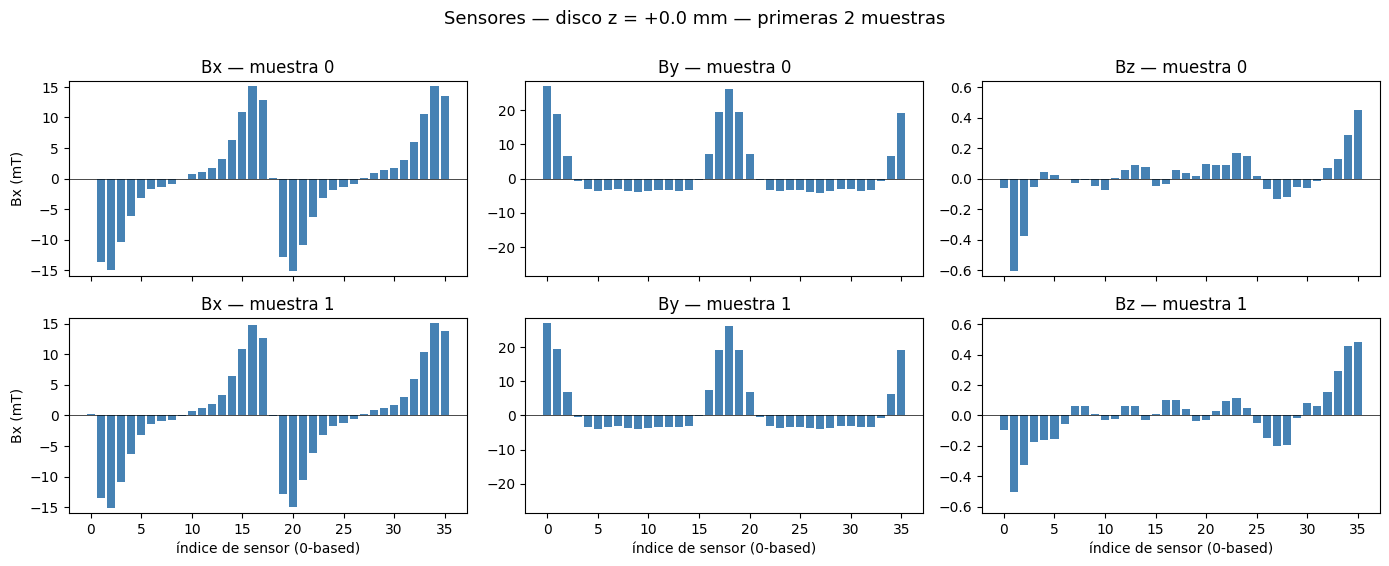

In [83]:
# Barras — Bx/By/Bz en los sensores, para las mismas 5 muestras
fig, axes = plt.subplots(N_SHOW, 3, figsize=(14, 2.8 * N_SHOW), squeeze=False, sharex=True)

# límites Y compartidos por componente para comparar entre muestras
ymaxs = [float(np.max(np.abs(d["B_sens"][:N_SHOW, :, c]))) for c in range(3)]

for i in range(N_SHOW):
    for c, (name, ymax) in enumerate(zip(COMPONENTS, ymaxs)):
        ax = axes[i, c]
        ax.bar(range(n_sensores), d["B_sens"][i, :, c], color="steelblue")
        ax.axhline(0, color="k", lw=0.5)
        ax.set_ylim(-ymax * 1.05, ymax * 1.05)
        ax.set_title(f"{name} — muestra {i}")
        if i == N_SHOW - 1:
            ax.set_xlabel("índice de sensor (0-based)")
        if c == 0:
            ax.set_ylabel(f"{name} (mT)")

plt.suptitle(f"Sensores — disco z = {meta['z_disco']:+.1f} mm — primeras {N_SHOW} muestras",
             y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Split train / val / test + normalización

- Split determinístico con `np.random.permutation(SEED)`.
- Normalización z-score: media y desviación se ajustan **solo en train** y se aplican a val/test (evita fuga de información).

In [75]:
rng  = np.random.default_rng(SEED)
perm = rng.permutation(N)

n_test = max(1, int(round(N * TEST_FRAC))) if N > 2 else 0
n_val  = max(1, int(round(N * VAL_FRAC)))  if N > 1 else 0
n_train = N - n_val - n_test
if n_train < 1:
    n_train, n_val, n_test = N, 0, 0

idx_train = perm[:n_train]
idx_val   = perm[n_train:n_train + n_val]
idx_test  = perm[n_train + n_val:]

X_tr, y_tr = X_all[idx_train], y_all[idx_train]
X_va, y_va = X_all[idx_val],   y_all[idx_val]
X_te, y_te = X_all[idx_test],  y_all[idx_test]

# Normalización z-score (ajustada en train)
x_mean = X_tr.mean(axis=0)
x_std  = X_tr.std(axis=0) + 1e-8
y_mean = y_tr.mean(axis=0)
y_std  = y_tr.std(axis=0) + 1e-8

def norm_x(x): return (x - x_mean) / x_std
def norm_y(y): return (y - y_mean) / y_std
def denorm_y(yn): return yn * y_std + y_mean

Xn_tr, Xn_va, Xn_te = norm_x(X_tr), norm_x(X_va), norm_x(X_te)
yn_tr, yn_va, yn_te = norm_y(y_tr), norm_y(y_va), norm_y(y_te)

print(f"train: {n_train}   val: {n_val}   test: {n_test}")

train: 3500   val: 750   test: 750


In [76]:
def make_loader(X, y, batch_size, shuffle):
    if len(X) == 0:
        return None
    ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).float())
    return DataLoader(ds, batch_size=min(batch_size, len(X)), shuffle=shuffle, drop_last=False)

loader_tr = make_loader(Xn_tr, yn_tr, BATCH_SIZE, shuffle=True)
loader_va = make_loader(Xn_va, yn_va, BATCH_SIZE, shuffle=False)
loader_te = make_loader(Xn_te, yn_te, BATCH_SIZE, shuffle=False)

## 5. Modelo FCNN

Red fully-connected configurable: lista de capas ocultas, activación, dropout. La cabeza final es lineal.

In [77]:
_ACTIVATIONS = {"relu": nn.ReLU, "gelu": nn.GELU, "tanh": nn.Tanh}


class FCNN(nn.Module):
    def __init__(self, n_in, n_out, hidden_layers, activation="relu", dropout=0.0):
        super().__init__()
        act_cls = _ACTIVATIONS[activation]
        layers, prev = [], n_in
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), act_cls()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = FCNN(n_in, n_out, HIDDEN_LAYERS, activation=ACTIVATION, dropout=DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nParámetros entrenables: {n_params:,}")

FCNN(
  (net): Sequential(
    (0): Linear(in_features=2883, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=108, bias=True)
  )
)

Parámetros entrenables: 384,428


## 6. Entrenamiento

- Loss: MSE sobre `y` normalizado.
- Optimizador: Adam con weight decay.
- Early stopping: `PATIENCE` epochs sin mejorar val loss.

In [78]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.MSELoss()


def run_epoch(loader, train):
    if loader is None:
        return float("nan")
    model.train(train)
    tot_loss, tot_n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                pred = model(xb)
                loss = loss_fn(pred, yb)
        tot_loss += loss.item() * xb.size(0)
        tot_n    += xb.size(0)
    return tot_loss / tot_n


history = {"train": [], "val": []}
best_val = float("inf")
best_state = None
epochs_no_improve = 0

for epoch in range(1, N_EPOCHS + 1):
    tr_loss = run_epoch(loader_tr, train=True)
    va_loss = run_epoch(loader_va, train=False)
    history["train"].append(tr_loss)
    history["val"].append(va_loss)

    ref_loss = va_loss if loader_va is not None else tr_loss
    if ref_loss < best_val - 1e-6:
        best_val = ref_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch == 1 or epoch % 10 == 0 or epoch == N_EPOCHS:
        print(f"epoch {epoch:4d}  train={tr_loss:.4e}  val={va_loss:.4e}  best={best_val:.4e}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping en epoch {epoch} (best val = {best_val:.4e})")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print("\nEntrenamiento finalizado.")

epoch    1  train=9.9228e-01  val=9.7760e-01  best=9.7760e-01
epoch   10  train=7.7840e-01  val=8.2077e-01  best=8.2077e-01
epoch   20  train=7.1386e-01  val=7.9200e-01  best=7.9117e-01
epoch   30  train=6.8196e-01  val=7.7901e-01  best=7.7901e-01
epoch   40  train=6.6524e-01  val=7.7743e-01  best=7.7548e-01
epoch   50  train=6.4941e-01  val=7.7516e-01  best=7.7084e-01
epoch   60  train=6.3645e-01  val=7.6762e-01  best=7.6762e-01
epoch   70  train=6.2746e-01  val=7.7190e-01  best=7.6533e-01
epoch   80  train=6.1726e-01  val=7.6918e-01  best=7.6326e-01
epoch   90  train=6.1446e-01  val=7.6322e-01  best=7.6322e-01
epoch  100  train=6.0722e-01  val=7.6320e-01  best=7.6076e-01
epoch  110  train=6.0431e-01  val=7.6151e-01  best=7.6057e-01
epoch  120  train=5.9769e-01  val=7.6051e-01  best=7.6051e-01
epoch  130  train=5.9202e-01  val=7.6094e-01  best=7.6031e-01
epoch  140  train=5.9126e-01  val=7.6214e-01  best=7.6031e-01
epoch  150  train=5.8885e-01  val=7.6280e-01  best=7.6015e-01
epoch  1

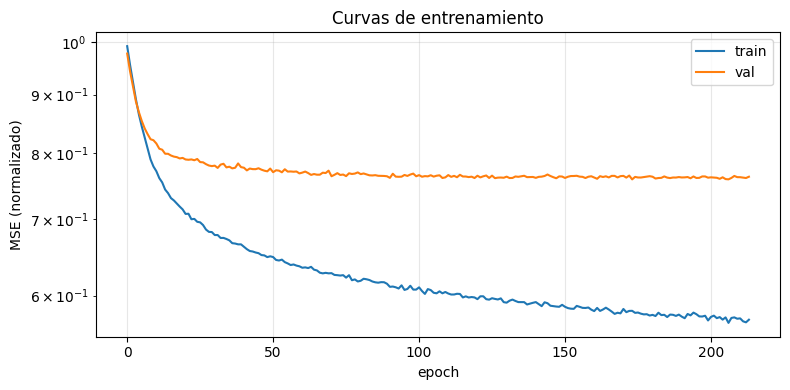

In [79]:
plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="train")
if loader_va is not None:
    plt.plot(history["val"], label="val")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("MSE (normalizado)")
plt.title("Curvas de entrenamiento")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Evaluación

Métricas sobre el set de **test** (en unidades físicas mT, tras desnormalizar):
- RMSE global y por componente (Bx, By, Bz) — solo si `OUTPUT_COMPONENTS = 'xyz'`.
- R² global y por sensor.

In [80]:
def predict(X_norm):
    model.eval()
    with torch.no_grad():
        xb = torch.from_numpy(X_norm).float().to(DEVICE)
        yn = model(xb).cpu().numpy()
    return denorm_y(yn)


def metrics_block(name, X_norm, y_true):
    if len(X_norm) == 0:
        print(f"[{name}] vacío (N=0)")
        return None
    y_pred = predict(X_norm)
    err    = y_pred - y_true
    rmse   = np.sqrt(np.mean(err ** 2))
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - y_true.mean(axis=0)) ** 2) + 1e-12
    r2     = 1 - ss_res / ss_tot
    print(f"[{name}]  RMSE={rmse:.4e} mT   R²={r2:+.4f}   (N={len(y_true)})")

    if OUTPUT_COMPONENTS == "xyz":
        K = n_sensores
        y_pred_r = y_pred.reshape(-1, 3, K)
        y_true_r = y_true.reshape(-1, 3, K)
        for c, lbl in enumerate(["Bx", "By", "Bz"]):
            r = np.sqrt(np.mean((y_pred_r[:, c] - y_true_r[:, c]) ** 2))
            print(f"    RMSE {lbl} = {r:.4e} mT")
    return y_pred


_ = metrics_block("train", Xn_tr, y_tr)
_ = metrics_block("val",   Xn_va, y_va)
y_pred_te = metrics_block("test", Xn_te, y_te)

[train]  RMSE=7.3682e-02 mT   R²=+0.5793   (N=3500)
    RMSE Bx = 7.4271e-02 mT
    RMSE By = 7.3340e-02 mT
    RMSE Bz = 7.3432e-02 mT
[val]  RMSE=9.7130e-02 mT   R²=+0.2802   (N=750)
    RMSE Bx = 9.8828e-02 mT
    RMSE By = 9.6315e-02 mT
    RMSE Bz = 9.6225e-02 mT
[test]  RMSE=9.6709e-02 mT   R²=+0.2607   (N=750)
    RMSE Bx = 9.8474e-02 mT
    RMSE By = 9.5509e-02 mT
    RMSE Bz = 9.6118e-02 mT


## 8. Predicciones vs verdad

Scatter de los valores reales contra los predichos (test set). En el caso ideal los puntos caen sobre la identidad.

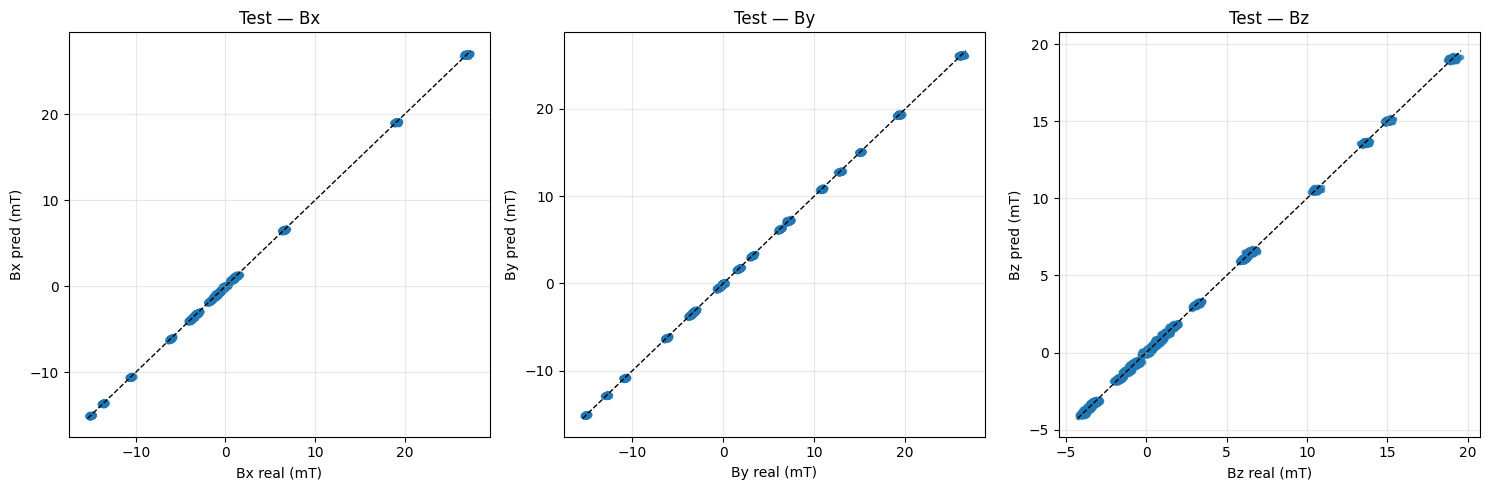

In [81]:
if y_pred_te is not None and len(y_te) > 0:
    if OUTPUT_COMPONENTS == "xyz":
        K = n_sensores
        y_true_r = y_te.reshape(-1, 3, K)
        y_pred_r = y_pred_te.reshape(-1, 3, K)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for c, (ax, lbl) in enumerate(zip(axes, ["Bx", "By", "Bz"])):
            t = y_true_r[:, c].ravel()
            p = y_pred_r[:, c].ravel()
            ax.scatter(t, p, s=10, alpha=0.6)
            lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
            ax.plot([lo, hi], [lo, hi], "k--", lw=1)
            ax.set_xlabel(f"{lbl} real (mT)")
            ax.set_ylabel(f"{lbl} pred (mT)")
            ax.set_title(f"Test — {lbl}")
            ax.grid(alpha=0.3)
    else:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(y_te.ravel(), y_pred_te.ravel(), s=10, alpha=0.6)
        lo = min(y_te.min(), y_pred_te.min())
        hi = max(y_te.max(), y_pred_te.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_xlabel("real (mT)"); ax.set_ylabel("predicho (mT)")
        ax.set_title("Test — predicción vs verdad")
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Test set vacío — no hay nada que plotear.")

## 9. Guardado del modelo y metadatos

Guarda pesos + normalizadores + config del run en `data/modelos/`. Para reutilizar: cargar el checkpoint y aplicar `norm_x` a las entradas nuevas, `denorm_y` a la predicción.

In [ ]:
ckpt_path = OUT_DIR / f"{RUN_TAG}.pt"
torch.save({
    "state_dict": model.state_dict(),
    "config": {
        "n_in": n_in, "n_out": n_out,
        "hidden_layers": HIDDEN_LAYERS,
        "activation": ACTIVATION,
        "dropout": DROPOUT,
        "input_components":  INPUT_COMPONENTS,
        "output_components": OUTPUT_COMPONENTS,
        "z_disco":    meta["z_disco"],
        "grid_shape": list(meta["grid_shape"]),
        "xy_min":     XY_MIN,
        "xy_max":     XY_MAX,
        "xy_step":    XY_STEP,
    },
    "scalers": {"x_mean": x_mean, "x_std": x_std, "y_mean": y_mean, "y_std": y_std},
    "history": history,
    "npz_path": str(NPZ_PATH),
}, ckpt_path)
print(f"Checkpoint guardado: {ckpt_path}")

## Próximos pasos

1. **Generar más muestras** desde el REPL de Julia (project `Ipre`):
   ```julia
   const BATCH_M = 64
   include("PMDKernel/kernel.jl")
   include("PMDKernel/utils/perturb.jl")
   include("PMDKernel/utils/disco.jl")

   paths = perturb_batch(500; kind=:both, sigma_deg=1f0)
   simular_disco_batch(0f0, paths;
       out_path="PMDKernel/data/simulaciones/disco_z0_both_n500.npz")
   ```
2. Apuntar `NPZ_PATH` al archivo nuevo y re-ejecutar el notebook.
3. Ajustar `HIDDEN_LAYERS`, `LR`, `N_EPOCHS` según el tamaño del dataset final.
4. Probar variantes: `INPUT_COMPONENTS = "z"` (solo Bz) o `OUTPUT_COMPONENTS = "z"`, comparar RMSE.
5. Para otros planos, llamar `simular_disco_batch` con otro `z_mm` ∈ {-128, -64, 64, 128}.

> **Nota.** `XY_STEP`, `XY_MIN` y `XY_MAX` del config-cell deben coincidir con los valores
> (`xy_step`, `grid_range`) usados en `simular_disco_batch`. Un desalineamiento se detecta en
> el loader via `assert` comparando la shape de `grid_xy` reconstruido con la de `B_grid`.